In [1]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

input_shape = (224, 224, 3)
data_dir = r"..\DFDC Dataset\dataset2"

real_data = [f for f in os.listdir(os.path.join(data_dir, "real")) if f.endswith(".png")]
fake_data = [f for f in os.listdir(os.path.join(data_dir, "fake")) if f.endswith(".png")]

X, Y = [], []

for img in real_data:
    arr = img_to_array(load_img(os.path.join(data_dir, "real", img), target_size=input_shape[:2])) / 255.0
    X.append(arr)
    Y.append(1)

for img in fake_data:
    arr = img_to_array(load_img(os.path.join(data_dir, "fake", img), target_size=input_shape[:2])) / 255.0
    X.append(arr)
    Y.append(0)

X = np.array(X, dtype="float32")
Y = to_categorical(Y, 2)

from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.25, random_state=5)

print("✅ Dataset ready")
print("Train set:", X_train.shape, Y_train.shape)
print("Validation set:", X_val.shape, Y_val.shape)

✅ Dataset ready
Train set: (6801, 224, 224, 3) (6801, 2)
Validation set: (2268, 224, 224, 3) (2268, 2)


In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers

input_shape = (224, 224, 3)

base_model = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)

base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-5, beta_1=0.9, beta_2=0.999),
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 24,059,650 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [4]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=8,
    verbose=1,
    mode='auto',
    restore_best_weights=True
)

EPOCHS = 50
BATCH_SIZE = 6

callback = [early_stopping]

history = model.fit(
    X_train, Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    verbose=1,
    callbacks=callback
)

Epoch 1/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 698s 615ms/step - accuracy: 0.9644 - loss: 0.1013 - val_accuracy: 0.9806 - val_loss: 0.0585
Epoch 2/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 688s 607ms/step - accuracy: 0.9850 - loss: 0.0476 - val_accuracy: 0.9713 - val_loss: 0.0779
Epoch 3/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 691s 609ms/step - accuracy: 0.9908 - loss: 0.0301 - val_accuracy: 0.9757 - val_loss: 0.0610
Epoch 4/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 687s 606ms/step - accuracy: 0.9946 - loss: 0.0223 - val_accuracy: 0.9872 - val_loss: 0.0392
Epoch 5/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 678s 598ms/step - accuracy: 0.9936 - loss: 0.0192 - val_accuracy: 0.9859 - val_loss: 0.0451
Epoch 6/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 680s 599ms/step - accuracy: 0.9964 - loss: 0.0093 - val_accuracy: 0.9727 - val_loss: 0.0785
Epoch 7/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 675s 595ms/step - accuracy: 0.9950 - loss: 0.0146 - val_accuracy: 0.9744 - val_loss: 0.0644
Epoch 8/50
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 673s 594ms/step - ac

In [5]:
import os

save_path = r"..\DFDC Dataset\models"

os.makedirs(save_path, exist_ok=True)

model.save(os.path.join(save_path, "model_resnet50.keras"))

model.save(os.path.join(save_path, "model_resnet50.h5"))

In [6]:
model.save("model_resnet50.keras")

In [7]:
model.save("model_resnet50.h5")

In [2]:
import os
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import img_to_array, load_img

model_path = r"..\DFDC Dataset\models\model_resnet50.keras"
data_dir = r"..\DFDC Dataset\dataset2"

print("🔄 Loading model...")
model = load_model(model_path)
print("✅ Model loaded!")

input_shape = (224, 224, 3)
X_test, Y_test, file_names = [], [], []

for img in os.listdir(os.path.join(data_dir, "real")):
    if img.lower().endswith((".png", ".jpg")):
        arr = img_to_array(load_img(os.path.join(data_dir, "real", img), target_size=input_shape[:2])) / 255.0
        X_test.append(arr)
        Y_test.append(1)   # REAL = 1
        file_names.append(img)

for img in os.listdir(os.path.join(data_dir, "fake")):
    if img.lower().endswith((".png", ".jpg")):
        arr = img_to_array(load_img(os.path.join(data_dir, "fake", img), target_size=input_shape[:2])) / 255.0
        X_test.append(arr)
        Y_test.append(0)   # FAKE = 0
        file_names.append(img)

X_test = np.array(X_test, dtype="float32")
Y_test = np.array(Y_test)

print("✅ Test dataset prepared:", X_test.shape, Y_test.shape)

print("🔎 Running evaluation...")
pred_probs = model.predict(X_test, batch_size=32)
pred_labels = np.argmax(pred_probs, axis=1) if pred_probs.shape[1] > 1 else (pred_probs > 0.5).astype("int32")

acc = accuracy_score(Y_test, pred_labels)
print(f"✅ Test Accuracy: {acc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, pred_labels))

print("\nClassification Report:")
print(classification_report(Y_test, pred_labels, target_names=["FAKE", "REAL"]))


🔄 Loading model...
✅ Model loaded!
✅ Test dataset prepared: (9069, 224, 224, 3) (9069,)
🔎 Running evaluation...
284/284 ━━━━━━━━━━━━━━━━━━━━ 181s 629ms/step
✅ Test Accuracy: 0.9956

Confusion Matrix:
[[8323   23]
 [  17  706]]

Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00      8346
        REAL       0.97      0.98      0.97       723

    accuracy                           1.00      9069
   macro avg       0.98      0.99      0.99      9069
weighted avg       1.00      1.00      1.00      9069



✅ Test Accuracy : 0.9956
✅ Precision     : 0.9684
✅ Recall        : 0.9765
✅ F1-score      : 0.9725

Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00      8346
        REAL       0.97      0.98      0.97       723

    accuracy                           1.00      9069
   macro avg       0.98      0.99      0.99      9069
weighted avg       1.00      1.00      1.00      9069



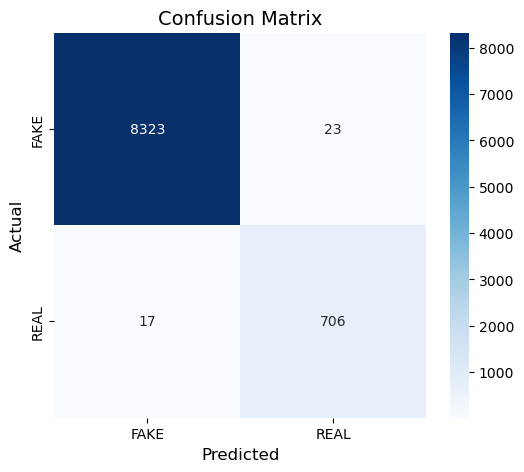

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(Y_test, pred_labels)
prec = precision_score(Y_test, pred_labels)
rec = recall_score(Y_test, pred_labels)
f1 = f1_score(Y_test, pred_labels)

print(f"✅ Test Accuracy : {acc:.4f}")
print(f"✅ Precision     : {prec:.4f}")
print(f"✅ Recall        : {rec:.4f}")
print(f"✅ F1-score      : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(Y_test, pred_labels, target_names=["FAKE", "REAL"]))

cm = confusion_matrix(Y_test, pred_labels)
labels = ["FAKE", "REAL"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.show()


In [4]:
acc = accuracy_score(Y_test, pred_labels) * 100
prec = precision_score(Y_test, pred_labels) * 100
rec = recall_score(Y_test, pred_labels) * 100
f1 = f1_score(Y_test, pred_labels) * 100

print(f"✅ Test Accuracy : {acc:.2f}%")
print(f"✅ Precision     : {prec:.2f}%")
print(f"✅ Recall        : {rec:.2f}%")
print(f"✅ F1-score      : {f1:.2f}%")

print("\nClassification Report:")
print(classification_report(Y_test, pred_labels, target_names=["FAKE", "REAL"]))


✅ Test Accuracy : 99.56%
✅ Precision     : 96.84%
✅ Recall        : 97.65%
✅ F1-score      : 97.25%

Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00      8346
        REAL       0.97      0.98      0.97       723

    accuracy                           1.00      9069
   macro avg       0.98      0.99      0.99      9069
weighted avg       1.00      1.00      1.00      9069

